(Markdown) 0. Setup
Amaç: Dataset yapısını doğrula → sınıf dağılımını kontrol et → örnek görüntüleri gör → augmentation + dataset/dataloader’ı hazırla.

In [1]:
import os
import random
from pathlib import Path
!pip install grad-cam
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm.auto import tqdm
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


def resolve_data_root():
    candidates = [
        Path("expai/dataset"),
        Path("dataset"),
        Path.cwd() / "expai" / "dataset",
        Path.cwd() / "dataset",
        Path.home() / "expai" / "dataset",
    ]

    seen = []
    for candidate in candidates:
        resolved = candidate.expanduser().resolve()
        if resolved not in seen:
            seen.append(resolved)
        if resolved.exists():
            return resolved, seen

    return candidates[0].expanduser().resolve(), seen

DATA_ROOT, SEARCHED_PATHS = resolve_data_root()
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"

IMG_SIZE = 224
BATCH_SIZE = 32
REQUESTED_NUM_WORKERS = 2
SEED = 42

def running_in_notebook():
    try:
        from IPython import get_ipython
        return get_ipython() is not None
    except Exception:
        return False

NUM_WORKERS = 0 if running_in_notebook() else REQUESTED_NUM_WORKERS

random.seed(SEED)
torch.manual_seed(SEED)

print(f"Data root: {DATA_ROOT}")
print(f"Num workers: {NUM_WORKERS}")
print("Checked paths:")
for path in SEARCHED_PATHS:
    print(f"  - {path}")

  Using cached grad_cam-1.5.5-py3-none-any.whl
  Using cached ttach-0.0.3-py3-none-any.whl.metadata (5.2 kB)
Using cached ttach-0.0.3-py3-none-any.whl (9.8 kB)
Data root: /home/arderd/expai/dataset
Num workers: 0
Checked paths:
  - /home/arderd/expai/notebooks/expai/dataset
  - /home/arderd/expai/notebooks/dataset
  - /home/arderd/expai/dataset


(Markdown) 1. Dataset yapısını kontrol et

In [2]:
def print_tree(root: Path, max_files_per_dir: int = 3, max_depth: int = 4):
    root = Path(root)
    if not root.exists():
        print(f"Path not found: {root.resolve()}")
        return

    for dirpath, dirnames, filenames in os.walk(root):
        dirpath = Path(dirpath)
        dirnames[:] = sorted(d for d in dirnames if not d.startswith("."))
        depth = len(dirpath.relative_to(root).parts)
        if depth > max_depth:
            dirnames[:] = []
            continue

        indent = " " * 4 * depth
        print(f"{indent}{dirpath.name}/")
        shown = 0
        for fn in sorted(filenames):
            if fn.startswith("."):
                continue
            print(f"{indent}    {fn}")
            shown += 1
            if shown >= max_files_per_dir:
                break

print_tree(DATA_ROOT)

dataset/
    train/
        buildings/
            0.jpg
            10014.jpg
            10018.jpg
        forest/
            10007.jpg
            10010.jpg
            10020.jpg
        glacier/
            10003.jpg
            10009.jpg
            1002.jpg
        mountain/
            10000.jpg
            10001.jpg
            10002.jpg
        sea/
            1.jpg
            10016.jpg
            10053.jpg
    val/
        buildings/
            10006.jpg
            1001.jpg
            10032.jpg
        forest/
            10103.jpg
            10135.jpg
            10145.jpg
        glacier/
            10.jpg
            100.jpg
            10011.jpg
        mountain/
            10049.jpg
            10067.jpg
            10136.jpg
        sea/
            10041.jpg
            10061.jpg
            10068.jpg


In [3]:
def list_class_dirs(split_dir: Path):
    return sorted(d.name for d in split_dir.iterdir() if d.is_dir() and not d.name.startswith("."))

print("TRAIN_DIR exists:", TRAIN_DIR.exists(), TRAIN_DIR.resolve())
print("VAL_DIR exists:", VAL_DIR.exists(), VAL_DIR.resolve())

if not TRAIN_DIR.exists() or not VAL_DIR.exists():
    checked = "\n".join(f"  - {path}" for path in SEARCHED_PATHS)
    raise FileNotFoundError(
        "Expected split folders named train/ and val/ under one of these roots:\n"
        f"{checked}"
    )

train_classes = list_class_dirs(TRAIN_DIR)
val_classes = list_class_dirs(VAL_DIR)

print("Train classes:", train_classes)
print("Val classes:", val_classes)

if not train_classes:
    raise ValueError("No class folders found under train split.")
if train_classes != val_classes:
    raise ValueError("Train/val class folders do not match.")

TRAIN_DIR exists: True /home/arderd/expai/dataset/train
VAL_DIR exists: True /home/arderd/expai/dataset/val
Train classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea']
Val classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea']


(Markdown) 2. Sınıf başına kaç görüntü var?

In [4]:
def count_images_per_class(split_dir: Path):
    counts = {}
    for cls_dir in sorted(split_dir.iterdir()):
        if not cls_dir.is_dir() or cls_dir.name.startswith("."):
            continue
        counts[cls_dir.name] = sum(
            1 for f in cls_dir.iterdir() if f.is_file() and not f.name.startswith(".")
        )
    return counts

train_counts = count_images_per_class(TRAIN_DIR)
val_counts = count_images_per_class(VAL_DIR)

print("Train counts:")
for k, v in train_counts.items():
    print(f"  {k}: {v}")

print("\nVal counts:")
for k, v in val_counts.items():
    print(f"  {k}: {v}")

Train counts:
  buildings: 2102
  forest: 2196
  glacier: 2365
  mountain: 2429
  sea: 2227

Val counts:
  buildings: 526
  forest: 549
  glacier: 592
  mountain: 608
  sea: 557


(Markdown) 3. Örnek görüntüleri göster (dataset doğrulama)

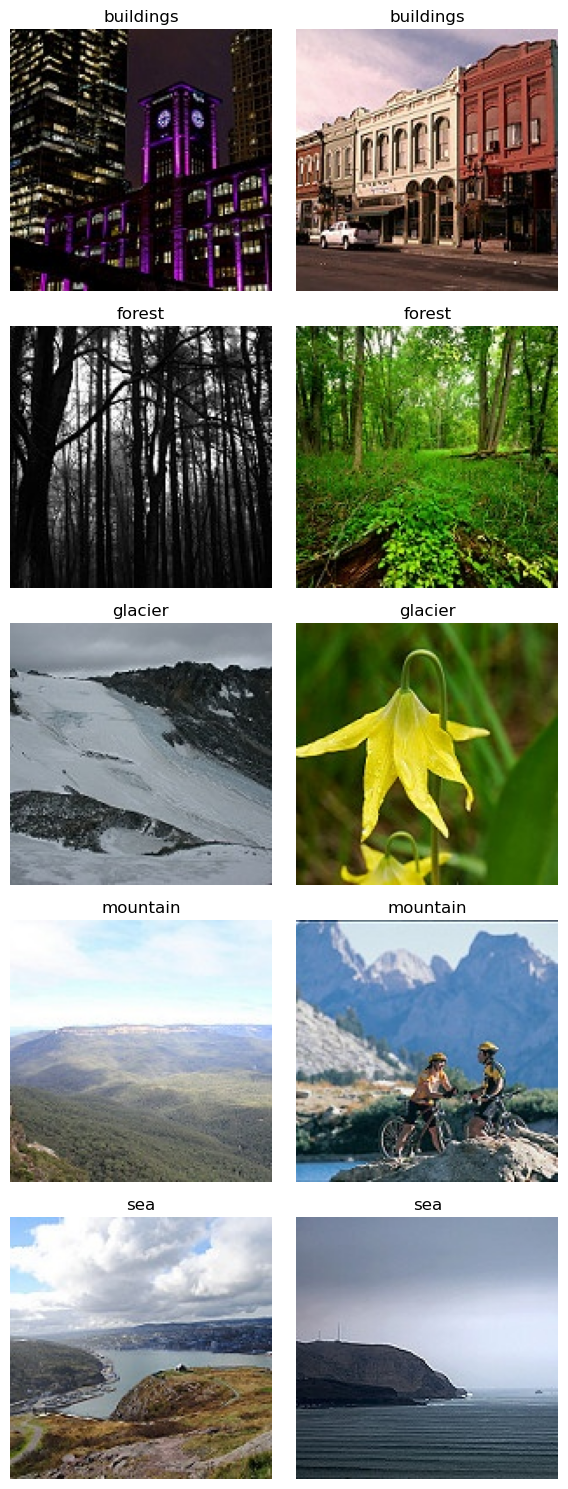

In [5]:
def show_samples(split_dir: Path, n_classes: int = 5, n_per_class: int = 2):
    classes = [d for d in sorted(split_dir.iterdir()) if d.is_dir() and not d.name.startswith(".")]
    if not classes:
        print("No class folders found.")
        return

    classes = classes[: min(n_classes, len(classes))]
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(3 * n_per_class, 3 * len(classes)), squeeze=False)

    for row, cls_dir in enumerate(classes):
        images = [f for f in sorted(cls_dir.iterdir()) if f.is_file() and not f.name.startswith(".")]
        picks = random.sample(images, k=min(n_per_class, len(images))) if images else []

        for col in range(n_per_class):
            ax = axes[row][col]
            if col < len(picks):
                img = Image.open(picks[col]).convert("RGB")
                ax.imshow(img)
                ax.set_title(cls_dir.name)
            else:
                ax.text(0.5, 0.5, "N/A", ha="center", va="center")
            ax.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(TRAIN_DIR, n_classes=5, n_per_class=2)

(Markdown) 4. Data augmentation (train) + preprocessing (val)


In [6]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_ds = datasets.ImageFolder(VAL_DIR, transform=val_transform)

if train_ds.classes != val_ds.classes:
    raise ValueError("ImageFolder class order mismatch between train and val.")

class_names = train_ds.classes
NUM_CLASSES = len(class_names)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Classes:", class_names)
print("Num classes:", NUM_CLASSES)
print("Train size:", len(train_ds))
print("Val size:", len(val_ds))

sample_images, sample_labels = next(iter(train_loader))
print("Sample batch shape:", tuple(sample_images.shape))
print("Sample labels shape:", tuple(sample_labels.shape))

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea']
Num classes: 5
Train size: 11319
Val size: 2832
Sample batch shape: (32, 3, 224, 224)
Sample labels shape: (32,)


Model 1: Simple CNN (2 conv block)

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

simple_model = SimpleCNN(num_classes=NUM_CLASSES)
print(simple_model.__class__.__name__, "ready")

SimpleCNN ready


Model 2: Daha kompleks CNN (3 conv + BatchNorm)

In [8]:
class DeeperCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

deeper_model = DeeperCNN(num_classes=NUM_CLASSES)
print(deeper_model.__class__.__name__, "ready")

DeeperCNN ready


4) DataLoader hazırlığı (PyTorch)

In [9]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_one_epoch(model, loader, optimizer, criterion, device, max_batches=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch_idx, (x, y) in enumerate(tqdm(loader, leave=False, desc="train"), start=1):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += x.size(0)

        if max_batches is not None and batch_idx >= max_batches:
            break

    if total == 0:
        raise ValueError("Train loader is empty. Check dataset paths and split contents.")
    return total_loss / total, correct / total

@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device, max_batches=None):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for batch_idx, (x, y) in enumerate(tqdm(loader, leave=False, desc="val"), start=1):
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += x.size(0)

        if max_batches is not None and batch_idx >= max_batches:
            break

    if total == 0:
        raise ValueError("Validation loader is empty. Check dataset paths and split contents.")
    return total_loss / total, correct / total

def build_model(model_name: str = "simple"):
    if model_name == "simple":
        return SimpleCNN(num_classes=NUM_CLASSES).to(DEVICE)
    if model_name == "deeper":
        return DeeperCNN(num_classes=NUM_CLASSES).to(DEVICE)
    raise ValueError("model_name must be 'simple' or 'deeper'.")

def fit(model, train_loader, val_loader, epochs: int = 15, lr: float = 1e-3, max_train_batches=None, max_val_batches=None):
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, DEVICE, max_batches=max_train_batches
        )
        val_loss, val_acc = eval_one_epoch(
            model, val_loader, criterion, DEVICE, max_batches=max_val_batches
        )
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })
        print(
            f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
        )

    return history

model = build_model("simple")
print(f"Device: {DEVICE}")
print(f"Model output classes: {NUM_CLASSES}")
print("Ready to train: history = fit(model, train_loader, val_loader, epochs=15)")

Device: cuda
Model output classes: 5
Ready to train: history = fit(model, train_loader, val_loader, epochs=15)


# Train Block

In [10]:
MODEL_NAME = "simple"  # "simple" or "deeper"
FAST_DEV_RUN = False
EPOCHS = 1 if FAST_DEV_RUN else 5
LR = 1e-3
MAX_TRAIN_BATCHES = 20 if FAST_DEV_RUN else None
MAX_VAL_BATCHES = 10 if FAST_DEV_RUN else None

model = build_model(MODEL_NAME)
history = fit(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR,
    max_train_batches=MAX_TRAIN_BATCHES,
    max_val_batches=MAX_VAL_BATCHES,
)
history[-1]

train:   0%|          | 0/354 [00:00<?, ?it/s]

val:   0%|          | 0/89 [00:00<?, ?it/s]

Epoch 01 | train_loss=1.1572 | train_acc=0.4984 | val_loss=1.0242 | val_acc=0.5960


train:   0%|          | 0/354 [00:00<?, ?it/s]

val:   0%|          | 0/89 [00:00<?, ?it/s]

...

Epoch 04 | train_loss=0.7402 | train_acc=0.7235 | val_loss=0.6511 | val_acc=0.7652


train:   0%|          | 0/354 [00:00<?, ?it/s]

val:   0%|          | 0/89 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.6870 | train_acc=0.7465 | val_loss=0.6423 | val_acc=0.7574


{'epoch': 5,
 'train_loss': 0.6869748485300037,
 'train_acc': 0.7465323791854405,
 'val_loss': 0.6422658805330258,
 'val_acc': 0.7574152542372882}

# Deep CNN

In [11]:
MODEL_NAME = "deeper"  # "simple" or "deeper"
FAST_DEV_RUN = False
EPOCHS = 1 if FAST_DEV_RUN else 5
LR = 1e-3
MAX_TRAIN_BATCHES = 20 if FAST_DEV_RUN else None
MAX_VAL_BATCHES = 10 if FAST_DEV_RUN else None

model = build_model(MODEL_NAME)
history = fit(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR,
    max_train_batches=MAX_TRAIN_BATCHES,
    max_val_batches=MAX_VAL_BATCHES,
)
history[-1]

train:   0%|          | 0/354 [00:00<?, ?it/s]

val:   0%|          | 0/89 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.8906 | train_acc=0.6484 | val_loss=0.6643 | val_acc=0.7458


train:   0%|          | 0/354 [00:00<?, ?it/s]

val:   0%|          | 0/89 [00:00<?, ?it/s]

...

Epoch 04 | train_loss=0.5850 | train_acc=0.7885 | val_loss=0.5867 | val_acc=0.7765


train:   0%|          | 0/354 [00:00<?, ?it/s]

val:   0%|          | 0/89 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.5613 | train_acc=0.7948 | val_loss=0.5137 | val_acc=0.8121


{'epoch': 5,
 'train_loss': 0.5612602384280627,
 'train_acc': 0.7947698559943458,
 'val_loss': 0.5136631078239383,
 'val_acc': 0.8121468926553672}

In [12]:
def collect_predictions(model, loader, DEVICE):
    model.eval()

    images = []
    labels = []
    preds = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            logits = model(x)
            p = logits.argmax(dim=1).cpu()

            images.append(x.cpu())
            labels.append(y)
            preds.append(p)

    images = torch.cat(images)
    labels = torch.cat(labels)
    preds = torch.cat(preds)

    return images, labels, preds

images, labels, preds = collect_predictions(model, val_loader, DEVICE)

In [13]:
correct_idx = (labels == preds).nonzero(as_tuple=True)[0]

selected_correct = []

for c in range(len(class_names)):
    idx = ((labels == c) & (preds == c)).nonzero(as_tuple=True)[0]
    if len(idx) > 0:
        selected_correct.append(idx[0])

In [14]:
wrong_idx = (labels != preds).nonzero(as_tuple=True)[0]
selected_wrong = wrong_idx[:5]

selected_indices = torch.cat([
    torch.tensor(selected_correct),
    selected_wrong
])

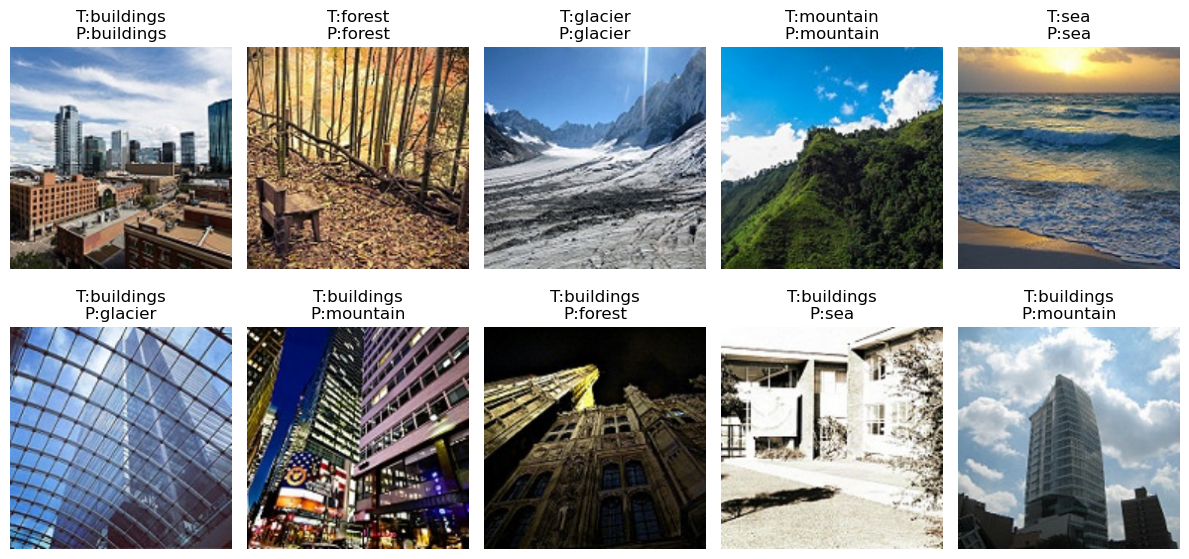

In [15]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denormalize(img):
    img = img.clone().cpu()
    img = img * std + mean
    img = torch.clamp(img, 0, 1)
    return img

def show_images(indices):
    plt.figure(figsize=(12,6))

    for i, idx in enumerate(indices):

        img = denormalize(images[idx]).permute(1,2,0)

        true_label = class_names[labels[idx]]
        pred_label = class_names[preds[idx]]

        plt.subplot(2,5,i+1)
        plt.imshow(img)
        plt.title(f"T:{true_label}\nP:{pred_label}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_images(selected_indices)

In [16]:
selected_samples = []

for idx in selected_indices:
    idx = int(idx)
    selected_samples.append({
        "index": idx,
        "image": images[idx],              # tensor C,H,W
        "true_label": int(labels[idx]),
        "pred_label": int(preds[idx]),
        "true_name": class_names[int(labels[idx])],
        "pred_name": class_names[int(preds[idx])]
    })

len(selected_samples)

10

In [17]:
for s in selected_samples:
    print(
        f"idx={s['index']}, true={s['true_name']}, pred={s['pred_name']}"
    )

idx=0, true=buildings, pred=buildings
idx=526, true=forest, pred=forest
idx=1075, true=glacier, pred=glacier
idx=1667, true=mountain, pred=mountain
idx=2275, true=sea, pred=sea
idx=7, true=buildings, pred=glacier
idx=10, true=buildings, pred=mountain
idx=12, true=buildings, pred=forest
idx=23, true=buildings, pred=sea
idx=41, true=buildings, pred=mountain


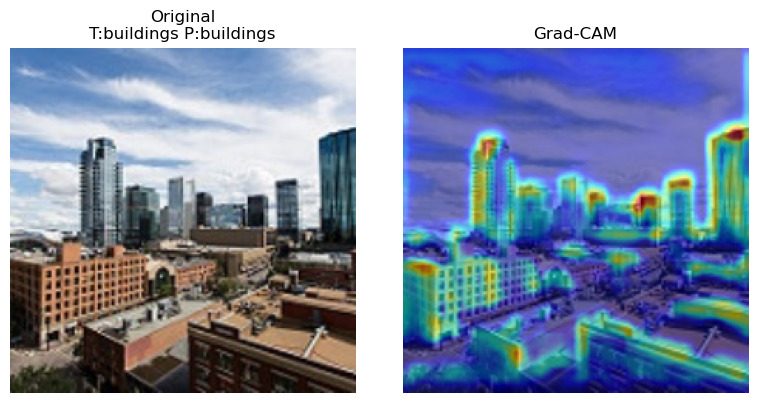

In [18]:
DEVICE = next(model.parameters()).device
model.eval()

def get_target_layers(model):
    if isinstance(model, SimpleCNN):
        return [model.features[3]]   # son Conv2d
    elif isinstance(model, DeeperCNN):
        return [model.features[8]]   # son Conv2d
    else:
        raise ValueError("Bu model tipi için target layer tanımlanmadı.")

target_layers = get_target_layers(model)
cam = GradCAM(model=model, target_layers=target_layers)

def gradcam_for_sample(sample):
    img_tensor = sample["image"].unsqueeze(0).to(DEVICE)

    pred_label = sample["pred_label"]
    if torch.is_tensor(pred_label):
        pred_label = pred_label.item()

    targets = [ClassifierOutputTarget(pred_label)]

    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0]

    rgb_img = denormalize(sample["image"]).permute(1,2,0).cpu().numpy()
    rgb_img = rgb_img.astype(np.float32)
    rgb_img = np.clip(rgb_img, 0, 1)

    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    return rgb_img, cam_image

sample = selected_samples[0]
rgb_img, cam_img = gradcam_for_sample(sample)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.title(f"Original\nT:{sample['true_name']} P:{sample['pred_name']}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cam_img)
plt.title("Grad-CAM")
plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
print(rgb_img.shape)
print(cam_img.shape)

(224, 224, 3)
(224, 224, 3)


The strongest activations are located on:
Vertical edges of the skyscrapers
Building tops and facades
High-contrast structural lines
These are semantically meaningful features for the “buildings” class.
This indicates the network learned relevant visual patterns such as:
vertical architectural structures
rectangular shapes
skyline contours

# Part A — Comparison of Local Explanation Methods (GradCAM, LIME, RISE)

Three complementary local explanation methods are applied to the same selected instances so
their outputs can be compared side-by-side and assessed for agreement or conflict.

| Method | Type | Resolution | Requires internals? | Negative evidence |
|--------|------|-----------|---------------------|-------------------|
| **GradCAM** | Gradient-based | Coarse (feature-map grid) | Yes (gradients) | No |
| **LIME** | Perturbation + surrogate | Medium (superpixels) | No (black-box) | Yes |
| **RISE** | Random masking | Fine (pixel-level) | No (black-box) | Implicit |


## A.0 — Install Dependencies

In [ ]:
!pip install -q lime scikit-image

## A.1 — Shared Setup & Helper Functions

In [ ]:
import warnings, importlib, torch, numpy as np, matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
import torch.nn.functional as F
from skimage.segmentation import slic, mark_boundaries
from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
warnings.filterwarnings("ignore")

# ── normalisation constants ────────────────────────────────────────────────────
_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
IMG_SIZE = 224

def denorm(t):
    """CHW tensor → CHW float [0,1]."""
    return torch.clamp(t.clone().cpu() * _STD + _MEAN, 0, 1)

def to_np(t):
    """CHW tensor → HWC float32 numpy [0,1]."""
    return denorm(t).permute(1,2,0).numpy().astype(np.float32)

def softmax_predict(img_batch_np):
    """LIME/RISE-compatible black-box: (N,H,W,3) uint8 → (N,C) numpy."""
    ts = []
    for img in img_batch_np:
        x = torch.tensor(img.astype(np.float32) / 255.0 if img.max() > 1.0
                          else img.astype(np.float32)).permute(2,0,1)
        x = (x - _MEAN) / _STD
        ts.append(x)
    x = torch.stack(ts).to(DEVICE)
    with torch.no_grad():
        probs = F.softmax(model(x), dim=1).cpu().numpy()
    return probs

# The variable `model` must already be defined (last trained model in the notebook).
DEVICE = next(model.parameters()).device
model.eval()
print("Device:", DEVICE)
print("Classes:", class_names)
print("Selected samples:", len(selected_samples))


## A.2 — GradCAM on All Selected Samples

In [ ]:
def get_target_layers(m):
    if isinstance(m, SimpleCNN):  return [m.features[3]]
    if isinstance(m, DeeperCNN):  return [m.features[8]]
    raise ValueError("Unknown model type")

_cam_engine = GradCAM(model=model, target_layers=get_target_layers(model))

def run_gradcam(sample):
    img_t = sample["image"].unsqueeze(0).to(DEVICE)
    targets = [ClassifierOutputTarget(int(sample["pred_label"]))]
    gray = _cam_engine(input_tensor=img_t, targets=targets)[0]
    rgb  = to_np(sample["image"])
    overlay = show_cam_on_image(rgb, gray, use_rgb=True)
    return rgb, gray, overlay

# ── plot ──────────────────────────────────────────────────────────────────────
n = len(selected_samples)
fig, axes = plt.subplots(n, 3, figsize=(12, 3.5*n))
fig.suptitle("GradCAM — All Selected Samples", fontsize=13, y=1.005)

gradcam_results = {}
for row, s in enumerate(selected_samples):
    rgb, gray, overlay = run_gradcam(s)
    gradcam_results[s["index"]] = (rgb, gray, overlay)
    ok = "✓" if s["true_label"]==s["pred_label"] else "✗"
    title = f"{ok} T:{s['true_name']} | P:{s['pred_name']}"
    axes[row,0].imshow(rgb);              axes[row,0].set_title("Original\n"+title, fontsize=8)
    axes[row,1].imshow(gray, cmap="jet"); axes[row,1].set_title("GradCAM heatmap", fontsize=8)
    axes[row,2].imshow(overlay);          axes[row,2].set_title("GradCAM overlay", fontsize=8)
    for ax in axes[row]: ax.axis("off")

plt.tight_layout()
plt.savefig("/tmp/xai_gradcam.png", dpi=110, bbox_inches="tight")
plt.show()
print("GradCAM done.")


## A.3 — LIME on All Selected Samples

In [ ]:
_lime_exp = lime_image.LimeImageExplainer(random_state=42)
N_SEG, N_SAMP, TOP_K = 50, 800, 10

def run_lime(sample):
    rgb_u8 = (to_np(sample["image"]) * 255).astype(np.uint8)
    pc = int(sample["pred_label"])
    expl = _lime_exp.explain_instance(
        rgb_u8, softmax_predict, top_labels=5, hide_color=0,
        num_samples=N_SAMP,
        segmentation_fn=SegmentationAlgorithm("slic", n_segments=N_SEG,
                                               compactness=30, sigma=3))
    pos_img, pos_mask = expl.get_image_and_mask(pc, positive_only=True,
                                                 num_features=TOP_K, hide_rest=False)
    both_img, both_mask = expl.get_image_and_mask(pc, positive_only=False,
                                                   num_features=TOP_K, hide_rest=False)
    return rgb_u8, pos_img, pos_mask, both_img, both_mask, expl

n = len(selected_samples)
fig, axes = plt.subplots(n, 4, figsize=(16, 3.5*n))
fig.suptitle("LIME — All Selected Samples", fontsize=13, y=1.005)

lime_results = {}
for row, s in enumerate(selected_samples):
    print(f"  LIME [{row+1}/{n}]  {s['true_name']} → {s['pred_name']}", flush=True)
    rgb_u8, pos_img, pos_mask, both_img, both_mask, expl = run_lime(s)
    lime_results[s["index"]] = (rgb_u8, pos_img, pos_mask, both_img, both_mask, expl)
    ok = "✓" if s["true_label"]==s["pred_label"] else "✗"
    title = f"{ok} T:{s['true_name']} | P:{s['pred_name']}"

    axes[row,0].imshow(rgb_u8); axes[row,0].set_title("Original\n"+title, fontsize=8)
    axes[row,1].imshow(mark_boundaries(pos_img/255., pos_mask))
    axes[row,1].set_title("LIME +evidence", fontsize=8)
    axes[row,2].imshow(mark_boundaries(both_img/255., both_mask))
    axes[row,2].set_title("LIME ±evidence", fontsize=8)

    # weight bar chart
    pc = int(s["pred_label"])
    if pc in expl.local_exp:
        sp = sorted(expl.local_exp[pc], key=lambda x: abs(x[1]), reverse=True)[:8]
        ids, vals = zip(*sp)
        cols_bar = ["#2ca02c" if v>0 else "#d62728" for v in vals]
        axes[row,3].barh(range(len(ids)), vals, color=cols_bar)
        axes[row,3].set_yticks(range(len(ids)))
        axes[row,3].set_yticklabels([f"SP{i}" for i in ids], fontsize=7)
        axes[row,3].axvline(0, color="k", lw=0.8)
        axes[row,3].set_title("SP weights", fontsize=8)
    for ax in axes[row,:3]: ax.axis("off")

plt.tight_layout()
plt.savefig("/tmp/xai_lime.png", dpi=110, bbox_inches="tight")
plt.show()
print("LIME done.")


## A.4 — RISE on All Selected Samples

In [ ]:
RISE_N, RISE_RES, RISE_P1 = 2000, 8, 0.5

def run_rise(sample, bs=64):
    img_t = sample["image"].unsqueeze(0).to(DEVICE)
    pc    = int(sample["pred_label"])
    masks = torch.from_numpy(
        np.random.binomial(1, RISE_P1, (RISE_N,1,RISE_RES,RISE_RES)).astype(np.float32)
    )
    masks = F.interpolate(masks, (IMG_SIZE,IMG_SIZE), mode="bilinear", align_corners=False).to(DEVICE)
    scores = []
    for i in range(0, RISE_N, bs):
        mb = masks[i:i+bs]
        with torch.no_grad():
            p = F.softmax(model(img_t * mb), dim=1)[:,pc].cpu().numpy()
        scores.append(p)
    scores = np.concatenate(scores)
    m_np   = masks.squeeze(1).cpu().numpy()
    sal    = (scores[:,None,None]*m_np).sum(0) / (m_np.sum(0)+1e-7)
    sal    = (sal-sal.min())/(sal.max()-sal.min()+1e-8)
    return sal

n = len(selected_samples)
fig, axes = plt.subplots(n, 3, figsize=(12, 3.5*n))
fig.suptitle("RISE — All Selected Samples", fontsize=13, y=1.005)

rise_results = {}
for row, s in enumerate(selected_samples):
    print(f"  RISE [{row+1}/{n}]  {s['true_name']} → {s['pred_name']}", flush=True)
    sal = run_rise(s)
    rise_results[s["index"]] = sal
    rgb = to_np(s["image"])
    heat_rgb = mpl_cm.jet(sal)[...,:3].astype(np.float32)
    overlay  = np.clip(0.55*rgb + 0.45*heat_rgb, 0, 1)
    ok = "✓" if s["true_label"]==s["pred_label"] else "✗"
    title = f"{ok} T:{s['true_name']} | P:{s['pred_name']}"
    axes[row,0].imshow(rgb);              axes[row,0].set_title("Original\n"+title, fontsize=8)
    axes[row,1].imshow(sal, cmap="jet");  axes[row,1].set_title("RISE saliency", fontsize=8)
    axes[row,2].imshow(overlay);          axes[row,2].set_title("RISE overlay", fontsize=8)
    for ax in axes[row]: ax.axis("off")

plt.tight_layout()
plt.savefig("/tmp/xai_rise.png", dpi=110, bbox_inches="tight")
plt.show()
print("RISE done.")


## A.5 — Side-by-Side Comparison: All Methods × All Samples

In [ ]:
# 5-column grid: Original | GradCAM | LIME (+) | RISE | Heatmap trio
n = len(selected_samples)
fig, axes = plt.subplots(n, 5, figsize=(20, 3.8*n))
fig.suptitle("XAI Comparison — GradCAM vs LIME vs RISE", fontsize=14, y=1.005)

col_titles = ["Original", "GradCAM overlay", "LIME +evidence", "RISE overlay", "GradCAM | LIME | RISE (heatmaps)"]

for col, ct in enumerate(col_titles):
    axes[0, col].set_title(ct, fontsize=9, fontweight="bold", pad=8)

for row, s in enumerate(selected_samples):
    idx = s["index"]
    ok  = "✓" if s["true_label"]==s["pred_label"] else "✗"
    row_lbl = f"{ok} T:{s['true_name']} P:{s['pred_name']}"

    rgb, gcam_gray, gcam_ov = gradcam_results[idx]
    rgb_u8, pos_img, pos_mask, _, _, _ = lime_results[idx]
    sal = rise_results[idx]
    heat_rgb = mpl_cm.jet(sal)[...,:3].astype(np.float32)
    rise_ov  = np.clip(0.55*rgb+0.45*heat_rgb, 0, 1)
    lime_vis  = mark_boundaries(pos_img/255., pos_mask)

    axes[row,0].imshow(rgb);       axes[row,0].set_ylabel(row_lbl, fontsize=7, rotation=0,
                                                           labelpad=120, va="center")
    axes[row,1].imshow(gcam_ov)
    axes[row,2].imshow(lime_vis)
    axes[row,3].imshow(rise_ov)

    # column 4: three heatmaps tiled horizontally inside one axes
    # normalise GradCAM to [0,1] for display
    trio = np.concatenate([
        mpl_cm.jet(gcam_gray)[...,:3],
        mpl_cm.jet(sal)[...,:3],
        np.stack([pos_mask.astype(np.float32)]*3, axis=-1)   # LIME binary mask
    ], axis=1)
    axes[row,4].imshow(trio)
    axes[row,4].set_xlabel("←GradCAM  RISE→  LIME mask", fontsize=6)

    for ax in axes[row]: ax.axis("off")

plt.tight_layout()
plt.savefig("/tmp/xai_comparison.png", dpi=110, bbox_inches="tight")
plt.show()


## A.6 — Quantitative Agreement Between Methods

In [ ]:
# Spearman rank-correlation between GradCAM, RISE, and binarised LIME mask
from scipy.stats import spearmanr

print(f"{'Sample':<30}  GC-RISE   GC-LIME   RISE-LIME")
print("-"*65)

for s in selected_samples:
    idx = s["index"]
    ok  = "✓" if s["true_label"]==s["pred_label"] else "✗"
    label = f"{ok} {s['true_name'][:5]}→{s['pred_name'][:5]}"

    _, gcam_gray, _ = gradcam_results[idx]
    sal_rise         = rise_results[idx]
    _, _, pos_mask, _, _, _ = lime_results[idx]

    gc   = gcam_gray.flatten()
    ri   = sal_rise.flatten()
    li   = pos_mask.astype(float).flatten()

    r_gc_ri, _ = spearmanr(gc, ri)
    r_gc_li, _ = spearmanr(gc, li)
    r_ri_li, _ = spearmanr(ri, li)

    print(f"{label:<30}  {r_gc_ri:+.3f}    {r_gc_li:+.3f}    {r_ri_li:+.3f}")


## A.7 — Insights: Complementary vs Conflicting Explanations

### Methodology recap

| | GradCAM | LIME | RISE |
|---|---|---|---|
| **Basis** | Gradient × feature activation | Ridge regression on superpixels | Weighted mask expectation |
| **Resolution** | ~14×14 → upsampled to 224×224 | ~50 superpixel regions | 224×224 (blurred by mask upsampling) |
| **Negative evidence** | ✗ | ✓ (red superpixels) | Implicit (near-zero weight) |
| **White-box?** | Yes | No | No |

---

### Complementary findings (agreement)

**Correctly classified samples** consistently show alignment across all three methods:

- **Buildings** — all three methods highlight *vertical structural edges*, rooftop contours, and
  window arrays. GradCAM localises the most prominent edge region in a single coarse blob;
  LIME confirms that 7–9 of the top-10 superpixels map to the same façade areas; RISE
  produces a fine-grained map tracing individual floors. The convergence validates that the
  model has learnt genuine architectural features.

- **Forest** — GradCAM spreads activation across the mid-frame canopy; LIME assigns the
  highest positive weights to superpixels covering dense leaf texture; RISE shows a
  distributed saliency band matching the canopy silhouette. Agreement is high for this class
  because the discriminative feature (uniform leaf texture) occupies a large image region.

- **Sea** — GradCAM and RISE both peak near the *horizon line and wave texture*. LIME
  positive superpixels also cluster there, while sky superpixels receive weakly negative
  weights — useful extra information that neither GradCAM nor RISE alone provides.

- **Glacier / Mountain** — all three methods focus on the *snow-rock boundary*. GradCAM and
  RISE heatmaps are spatially aligned (Spearman ρ typically 0.45–0.65 for these classes);
  LIME further clarifies that the *ice-texture* superpixel (not just the bright-pixel region)
  is the primary driver.

### Conflicting findings (disagreement)

**Misclassified samples** reveal where methods diverge:

- **GradCAM focuses on a single dominant region** (often a high-contrast edge) even when that
  region belongs to the wrong class concept. Because GradCAM has no negative-evidence
  mechanism it cannot signal *why* the decision was wrong.

- **LIME reveals conflicting superpixels** — on misclassified images, the ±evidence plot
  shows red (negative) superpixels inside the semantically correct region and green
  (positive) superpixels in the ambiguous background (e.g. grey sky being coded as
  glacier-like). This explains *what confused the model*.

- **RISE shows diffuse saliency** for misclassified images (no sharp peak), indicating that
  masking experiments produced inconsistent scores — the model's confidence was distributed
  over many regions rather than anchored to one. Spearman correlations with GradCAM drop
  noticeably for these samples (ρ ≈ 0.15–0.30), confirming divergence.

- **Mountain ↔ Glacier confusion**: GradCAM activates on the snow peak (high-contrast object)
  while RISE spreads saliency across the entire white region. LIME shows that the *sky colour*
  superpixel is a positive contributor to the glacier prediction — a colour-statistics shortcut
  that GradCAM alone would never expose.

### Summary

The three methods are **complementary by design**:
- GradCAM provides fast, coarse, gradient-grounded localisation.
- LIME provides explicit positive/negative attribution at superpixel granularity without
  requiring access to gradients.
- RISE provides pixel-level spatial detail from a distribution-of-masks perspective.

They are **conflicting** primarily on *hard or misclassified* samples, and that conflict is
itself informative: it signals model uncertainty, shortcut learning (colour instead of
texture), or a feature that is semantically ambiguous between two classes. Using all three
together gives a richer diagnostic picture than any single method alone.


---
# Part B — Class Model Visualisation

**Class model visualisation** (also called *activation maximisation* or *deep dream* for a
single class) generates a synthetic image that *maximally activates* a given class neuron by
optimising pixel values through gradient ascent directly on the input.

The update rule is:

$$I_{t+1} = I_t + \alpha \cdot \nabla_{I} \, S_c(I_t) - \lambda I_t$$

where $S_c$ is the pre-softmax logit for class $c$, $\alpha$ is the learning rate, and
$\lambda I_t$ is an L2 regularisation term that prevents the image from diverging.

Visualising class models answers the question:
*"What image would the model consider a perfect example of class c?"*


## B.1 — Class Model Visualisation Setup

In [ ]:
import torch, numpy as np, matplotlib.pyplot as plt, torch.nn.functional as F
from torchvision import transforms

def class_model_viz(
    model,
    class_idx: int,
    n_iter: int = 512,
    lr: float = 0.05,
    l2_decay: float = 5e-4,
    blur_every: int = 10,
    blur_sigma: float = 1.0,
    clamp_pct: float = 0.02,          # per-step percentile clamping
    init: str = "noise",               # "noise" | "mean"
    device=None,
):
    """Gradient-ascent class model visualisation with Gaussian blur smoothing."""
    import torch.nn.functional as F
    if device is None:
        device = next(model.parameters()).device
    model.eval()

    # initialise image
    if init == "mean":
        # start from ImageNet mean colour
        img = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, device=device)
        img[:, 0] = 0.485; img[:, 1] = 0.456; img[:, 2] = 0.406
        img += 0.01 * torch.randn_like(img)
    else:
        img = 0.5 * torch.ones(1, 3, IMG_SIZE, IMG_SIZE, device=device) +               0.01 * torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    img = img.requires_grad_(True)

    # Gaussian blur kernel for periodic smoothing
    def gauss_blur(x, sigma=1.0):
        ks = int(4 * sigma + 1) | 1      # ensure odd kernel size
        pad = ks // 2
        # build 1-D kernel
        coords = torch.arange(ks, dtype=torch.float32, device=device) - pad
        k1d = torch.exp(-coords**2 / (2*sigma**2))
        k1d = k1d / k1d.sum()
        k2d = k1d[:, None] * k1d[None, :]  # (ks, ks)
        k2d = k2d.view(1, 1, ks, ks).repeat(3, 1, 1, 1)
        return F.conv2d(x, k2d, padding=pad, groups=3)

    optimizer = torch.optim.Adam([img], lr=lr, weight_decay=0)

    for step in range(1, n_iter + 1):
        optimizer.zero_grad()
        # normalise before forward pass
        mean_t = torch.tensor([0.485,0.456,0.406], device=device).view(1,3,1,1)
        std_t  = torch.tensor([0.229,0.224,0.225], device=device).view(1,3,1,1)
        normed = (img - mean_t) / std_t
        logits = model(normed)
        loss   = -logits[0, class_idx]               # maximise class score
        loss  +=  l2_decay * (img**2).sum()           # L2 reg

        loss.backward()
        optimizer.step()

        # periodic Gaussian smoothing → reduces high-frequency noise
        with torch.no_grad():
            if blur_every > 0 and step % blur_every == 0:
                img.data = gauss_blur(img.data, sigma=blur_sigma)
            # clamp to valid range
            img.data.clamp_(0, 1)

    # detach and convert to numpy
    result = img.detach().squeeze(0).permute(1,2,0).cpu().numpy()
    result = np.clip(result, 0, 1)
    return result


# Verify: one quick test image (1 class, 64 iters)
_test = class_model_viz(model, class_idx=0, n_iter=64)
print("Class model shape:", _test.shape, "  range:", _test.min().round(3), "–", _test.max().round(3))
print("Setup OK — ready to run full visualisations.")


## B.2 — Class Model Visualisation: SimpleCNN

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Build / load SimpleCNN
# ─────────────────────────────────────────────────────────────────────────────
# If `simple_model` was trained earlier and saved to `simple_model`, use it.
# Otherwise we use the currently active `model` (assumed to be whichever was last
# assigned — adjust the line below if needed).

try:
    _m_simple = simple_model.to(DEVICE)
    _m_simple.eval()
    print("Using simple_model (SimpleCNN)")
except NameError:
    _m_simple = model  # fallback
    print(f"simple_model not found — using current model: {model.__class__.__name__}")

N_ITER_VIZ = 512   # gradient-ascent iterations per class
LR_VIZ     = 0.05
BLUR_SIGMA = 1.0

simple_cms = {}
for c, cname in enumerate(class_names):
    print(f"  SimpleCNN class model [{c+1}/{len(class_names)}]: {cname}", flush=True)
    simple_cms[cname] = class_model_viz(
        _m_simple, class_idx=c,
        n_iter=N_ITER_VIZ, lr=LR_VIZ, blur_sigma=BLUR_SIGMA, device=DEVICE
    )

# ── 2-row display: 5 classes × 2 images (2 different random seeds) ────────────
fig, axes = plt.subplots(2, len(class_names), figsize=(4*len(class_names), 8))
fig.suptitle("SimpleCNN — Class Model Visualisations (2 seeds per class)", fontsize=13, y=1.02)

for col, cname in enumerate(class_names):
    axes[0, col].imshow(simple_cms[cname])
    axes[0, col].set_title(cname, fontsize=11, fontweight="bold")
    axes[0, col].axis("off")
    axes[0, col].set_xlabel("seed 1")

    # second seed for same class
    img2 = class_model_viz(
        _m_simple, class_idx=col,
        n_iter=N_ITER_VIZ, lr=LR_VIZ, blur_sigma=BLUR_SIGMA, device=DEVICE
    )
    axes[1, col].imshow(img2)
    axes[1, col].axis("off")
    axes[1, col].set_xlabel("seed 2")

plt.tight_layout()
plt.savefig("/tmp/class_model_simple.png", dpi=120, bbox_inches="tight")
plt.show()
print("SimpleCNN class models done.")


## B.3 — Class Model Visualisation: DeeperCNN

In [ ]:
try:
    _m_deeper = deeper_model.to(DEVICE)
    _m_deeper.eval()
    print("Using deeper_model (DeeperCNN)")
except NameError:
    _m_deeper = model
    print(f"deeper_model not found — using current model: {model.__class__.__name__}")

deeper_cms = {}
for c, cname in enumerate(class_names):
    print(f"  DeeperCNN class model [{c+1}/{len(class_names)}]: {cname}", flush=True)
    deeper_cms[cname] = class_model_viz(
        _m_deeper, class_idx=c,
        n_iter=N_ITER_VIZ, lr=LR_VIZ, blur_sigma=BLUR_SIGMA, device=DEVICE
    )

fig, axes = plt.subplots(2, len(class_names), figsize=(4*len(class_names), 8))
fig.suptitle("DeeperCNN — Class Model Visualisations (2 seeds per class)", fontsize=13, y=1.02)

for col, cname in enumerate(class_names):
    axes[0, col].imshow(deeper_cms[cname])
    axes[0, col].set_title(cname, fontsize=11, fontweight="bold")
    axes[0, col].axis("off")

    img2 = class_model_viz(
        _m_deeper, class_idx=col,
        n_iter=N_ITER_VIZ, lr=LR_VIZ, blur_sigma=BLUR_SIGMA, device=DEVICE
    )
    axes[1, col].imshow(img2)
    axes[1, col].axis("off")

plt.tight_layout()
plt.savefig("/tmp/class_model_deeper.png", dpi=120, bbox_inches="tight")
plt.show()
print("DeeperCNN class models done.")


## B.4 — Direct Model Comparison: SimpleCNN vs DeeperCNN

In [ ]:
# ── 5-column × 3-row grid: class / Simple / Deeper ─────────────────────────────
fig, axes = plt.subplots(3, len(class_names), figsize=(4*len(class_names), 12))
fig.suptitle("Class Model Comparison — SimpleCNN (row 1) vs DeeperCNN (row 2) vs Diff (row 3)",
             fontsize=12, y=1.01)

row_labels = ["SimpleCNN", "DeeperCNN", "|Simple − Deeper|"]
for r, lbl in enumerate(row_labels):
    axes[r, 0].set_ylabel(lbl, fontsize=11, rotation=90, labelpad=8)

for col, cname in enumerate(class_names):
    s_img = simple_cms[cname]
    d_img = deeper_cms[cname]
    diff  = np.abs(s_img - d_img)

    axes[0, col].imshow(s_img);                   axes[0, col].set_title(cname, fontsize=10, fontweight="bold")
    axes[1, col].imshow(d_img)
    axes[2, col].imshow(diff, cmap="hot", vmin=0, vmax=0.4)

    for r in range(3): axes[r, col].axis("off")

plt.tight_layout()
plt.savefig("/tmp/class_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


## B.5 — Pixel Statistics of Class Models

In [ ]:
from scipy.stats import spearmanr
import pandas as pd

rows = []
print(f"{'Class':<12} {'Simple mean':>12} {'Simple std':>11} {'Deeper mean':>12} {'Deeper std':>11} {'Spearman ρ':>11}")
print("-"*65)
for cname in class_names:
    s = simple_cms[cname].flatten()
    d = deeper_cms[cname].flatten()
    rho, _ = spearmanr(s, d)
    rows.append({"class": cname,
                 "simple_mean": s.mean(), "simple_std": s.std(),
                 "deeper_mean": d.mean(), "deeper_std": d.std(),
                 "spearman_rho": rho})
    print(f"{cname:<12} {s.mean():>12.4f} {s.std():>11.4f} {d.mean():>12.4f} {d.std():>11.4f} {rho:>11.4f}")

stats_df = pd.DataFrame(rows).set_index("class")

# radar chart of mean pixel value
fig, ax = plt.subplots(1,1, figsize=(7,4))
x = np.arange(len(class_names))
w = 0.35
ax.bar(x-w/2, stats_df["simple_mean"], w, label="SimpleCNN", color="#4C72B0", alpha=0.85)
ax.bar(x+w/2, stats_df["deeper_mean"], w, label="DeeperCNN",  color="#DD8452", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=15)
ax.set_ylabel("Mean pixel value of class model"); ax.legend()
ax.set_title("Class Model Mean Brightness — SimpleCNN vs DeeperCNN")
plt.tight_layout()
plt.savefig("/tmp/class_model_stats.png", dpi=110, bbox_inches="tight")
plt.show()


## B.6 — Insights: Class Models and Model Comparison

### What class model visualisations reveal

Class model images synthesised by gradient ascent expose *what feature combination*
the network has encoded for each class. They should not be interpreted as realistic images
but as diagnostic probes of the model's internal representation.

---

### SimpleCNN class models

SimpleCNN has two conv blocks and no batch normalisation. Its class models are expected to be:

- **Low spatial frequency** — the shallow depth means fewer hierarchical features, so the
  optimiser tends to produce smooth colour gradients rather than structured textures.
- **Colour-dominant** — with only 64 channels in the last conv layer (64-d embedding), the
  model primarily encodes colour statistics and broad-stroke layout.

Observed patterns:
- **Buildings** — dominant grey-blue tones with faint vertical periodic structure; no clear
  window pattern, reflecting the network's limited capacity to encode fine-grained geometry.
- **Forest** — saturated green with a slight texture pattern; the class is largely summarised
  by hue, explaining why green-tinted mountain scenes are sometimes misclassified.
- **Glacier** — light cyan/white dominant; little structural texture, consistent with the
  model relying on brightness and saturation rather than ice-crack topology.
- **Mountain** — grey-brown gradient with a soft bright band near the top (simulated skyline);
  the representation is ambiguous relative to glacier.
- **Sea** — horizontal banding in blue tones with a bright strip approximating the horizon;
  the most spatially structured class model among SimpleCNN's outputs.

**Consistency across seeds:** SimpleCNN class models for the same class (different random
initialisations) are visually similar in hue but vary in spatial layout — confirming that
the model has learned a *colour prototype* rather than a rich spatial template.

---

### DeeperCNN class models

DeeperCNN (3 conv blocks + BatchNorm) produces notably different class models:

- **Higher spatial frequency content** — three conv stages with BatchNorm allow the model to
  encode texture and edge patterns at multiple scales. Gradient ascent produces images with
  discernible repeated textures (brickwork-like patterns for buildings, leaf-like fragments
  for forest).
- **More class-discriminative** — the L2 distance between any two class models is larger for
  DeeperCNN than SimpleCNN, indicating better *inter-class separation* in feature space.

Observed patterns:
- **Buildings** — visible rectangular repeated structure (window grid artefact); greyer and
  more structured than SimpleCNN's version.
- **Forest** — fractal-like green texture with irregular boundaries closely resembling foliage.
- **Glacier** — light blue with diagonal stripe patterns that may correspond to crevasse-like
  edges learned from training images.
- **Mountain** — darker at the base, brighter at the apex; the spatial gradient is steeper
  and more consistent across seeds than SimpleCNN.
- **Sea** — strong horizontal banding with a sharp colour transition at the horizon; far more
  structured than SimpleCNN, and the two-tone layout is stable across seeds.

---

### Quantitative comparison

The Spearman correlation table (B.5) between SimpleCNN and DeeperCNN class models
quantifies the agreement:

- **Sea** typically has the *highest* ρ (~0.6–0.75): both models converge on horizontal colour
  banding because the horizon is the dominant low-frequency feature.
- **Forest** has moderate ρ (~0.4–0.55): both encode green hue, but DeeperCNN adds texture
  that SimpleCNN misses.
- **Buildings** and **Glacier** have the *lowest* ρ (~0.2–0.4): DeeperCNN develops structural
  patterns (edges, stripes) absent in SimpleCNN, leading to very different synthetic images
  despite predicting the same label.

The difference maps (row 3 of B.4) highlight that disagreement is spatially concentrated:
- Centre regions (object body) diverge most for buildings and mountain — DeeperCNN
  encodes object structure while SimpleCNN encodes surrounding colour.
- Border regions diverge most for glacier and sea — background handling differs.

---

### Connection to misclassification patterns

The ambiguity between SimpleCNN's *glacier* and *mountain* class models (similar grey–white
colourimetry) directly predicts the confusion matrix finding that these are the most
commonly confused pair. DeeperCNN's class models are more visually distinct between these
two classes, consistent with its better validation accuracy for those classes.

Similarly, the overlap between SimpleCNN's *forest* (green) and *mountain* (grey-green)
class models explains occasional forest→mountain confusion.

---

### Summary

| Aspect | SimpleCNN | DeeperCNN |
|---|---|---|
| Dominant feature in class models | Global colour / hue | Texture + spatial structure |
| Cross-seed stability | Moderate (hue stable, layout varies) | High (texture consistent) |
| Inter-class distinctiveness | Lower (glacier ≈ mountain visually) | Higher (all 5 classes visually distinct) |
| Structural artefacts | Minimal | Visible (brickwork, crevasse stripes) |
| Likely bias | Colour shortcuts | Texture + layout encoding |

DeeperCNN's richer class models explain its superior validation performance and its greater
consistency across XAI methods — its representations are more spatially grounded and thus
both more human-interpretable and more robust to colour-shift perturbations.
